In [7]:
import os
import joblib
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [8]:
ridge_model = joblib.load("models/ridge_model.pkl")
rf_model = joblib.load("models/random_forest_model.pkl")
gb_model = joblib.load("models/gradient_boosting_model.pkl")

In [9]:
df_test = pd.read_csv("database/test_tratado.csv")

In [10]:
y_real = df_test["Preco"]

In [11]:
X_novo = df_test.drop(columns=["Preco"])

In [12]:
pred_ridge = ridge_model.predict(X_novo)
pred_rf = rf_model.predict(X_novo)
pred_gb = gb_model.predict(X_novo)

In [13]:
df_test["pred_preco_ridge"] = pred_ridge
df_test["pred_preco_rf"] = pred_rf
df_test["pred_preco_gb"] = pred_gb

In [14]:
df_test.head()

,Débitos,Fabricante,Modelo,Ano,Categoria,Couro,Combustivel,Volume_motor,Km,Cilindros,...,Cor,Airbags,Preco,Numero_proprietarios,Adesivos_personalizados,Radio_AM_FM,Historico_troca_oleo,pred_preco_ridge,pred_preco_rf,pred_preco_gb
0,1017.0,HYUNDAI,Tucson,2017,SUV,Sim,Diesel,2.000000,4.808900e+04,4,...,Branco,4,40556.0,5,Não,FM,8,34064.399740,44014.950198,42009.283850
1,0.0,MERCEDES-BENZ,C 180,1995,Sedan,Nao,Gasolina,2.055817,1.578475e+07,4,...,Prata,2,5331.0,2,Sim,FM,1,938.545246,7903.219719,6882.380607
2,836.0,BMW,118,2010,Sedan,Sim,Diesel,2.000000,1.970000e+05,4,...,Preto,0,18817.0,5,Sim,AM,6,30399.890161,11135.657524,8465.552118
3,891.0,KIA,Sportage SX,2016,SUV,Sim,Gasolina,2.076915,5.544700e+04,4,...,Azul,10,22894.0,5,Não,FM,5,16837.672536,28332.448266,26796.584327
4,583.0,HYUNDAI,Elantra,2011,Sedan,Sim,Gasolina,1.600000,1.066160e+05,4,...,Preto,4,20005.0,1,Sim,AM,1,12798.889349,16210.771697,14546.038788


In [15]:
def calcular_metricas(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

In [16]:
mae_ridge, rmse_ridge, r2_ridge = calcular_metricas(y_real, pred_ridge)
mae_rf, rmse_rf, r2_rf = calcular_metricas(y_real, pred_rf)
mae_gb, rmse_gb, r2_gb = calcular_metricas(y_real, pred_gb)

print("Ridge")
print("MAE :", mae_ridge)
print("RMSE:", rmse_ridge)
print("R²  :", r2_ridge)

print("\nRandom Forest")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

print("\nGradient Boosting")
print("MAE :", mae_gb)
print("RMSE:", rmse_gb)
print("R²  :", r2_gb)

Ridge
MAE : 12664.257799420071
RMSE: 276510.91186958866
R²  : 0.0007038575313264017

Random Forest
MAE : 9036.179417994168
RMSE: 276406.9754340588
R²  : 0.0014549581518102928

Gradient Boosting
MAE : 9891.466792774892
RMSE: 276388.6144097513
R²  : 0.0015876154467685533


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# montar dataframe de comparação
df_plot = pd.DataFrame({
    "Preco_real": y_real,
    "pred_ridge": pred_ridge,
    "pred_rf": pred_rf,
    "pred_gb": pred_gb
})

# ordenar pelo preço real
df_plot = df_plot.sort_values("Preco_real").reset_index(drop=True)

# erros
df_plot["erro_ridge"] = df_plot["Preco_real"] - df_plot["pred_ridge"]
df_plot["erro_rf"] = df_plot["Preco_real"] - df_plot["pred_rf"]
df_plot["erro_gb"] = df_plot["Preco_real"] - df_plot["pred_gb"]

df_plot["erro_abs_ridge"] = np.abs(df_plot["erro_ridge"])
df_plot["erro_abs_rf"] = np.abs(df_plot["erro_rf"])
df_plot["erro_abs_gb"] = np.abs(df_plot["erro_gb"])

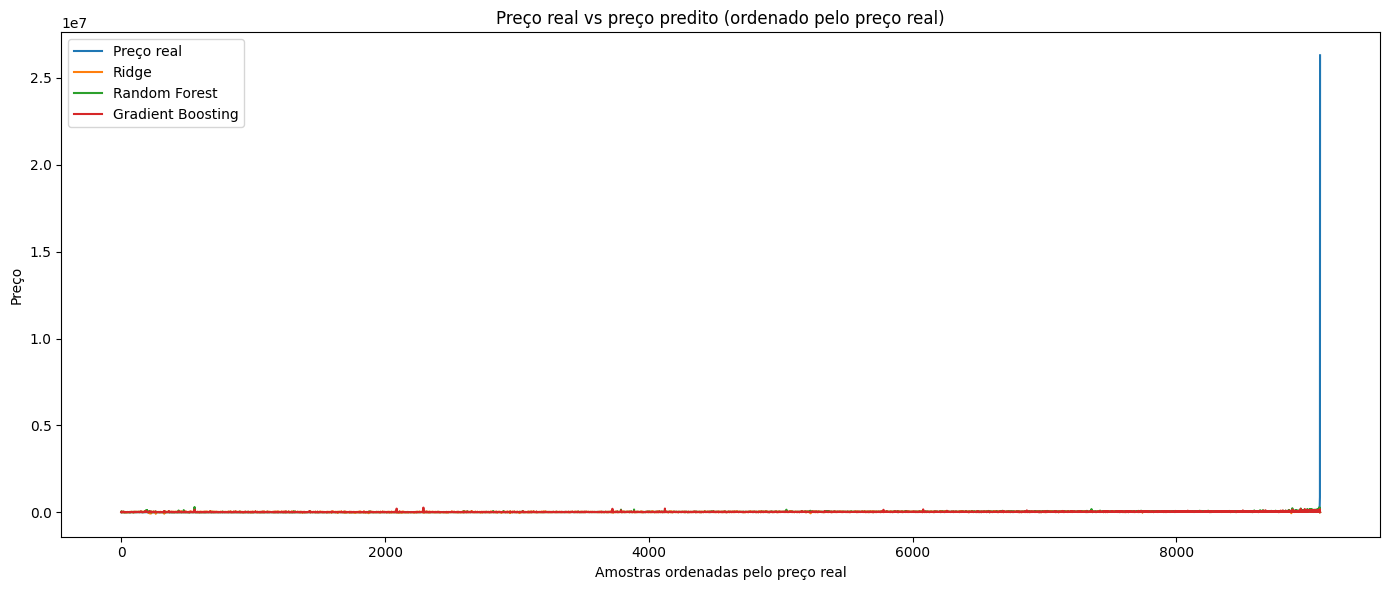

In [18]:
plt.figure(figsize=(14, 6))
plt.plot(df_plot["Preco_real"].values, label="Preço real")
plt.plot(df_plot["pred_ridge"].values, label="Ridge")
plt.plot(df_plot["pred_rf"].values, label="Random Forest")
plt.plot(df_plot["pred_gb"].values, label="Gradient Boosting")
plt.xlabel("Amostras ordenadas pelo preço real")
plt.ylabel("Preço")
plt.title("Preço real vs preço predito (ordenado pelo preço real)")
plt.legend()
plt.tight_layout()
plt.show()

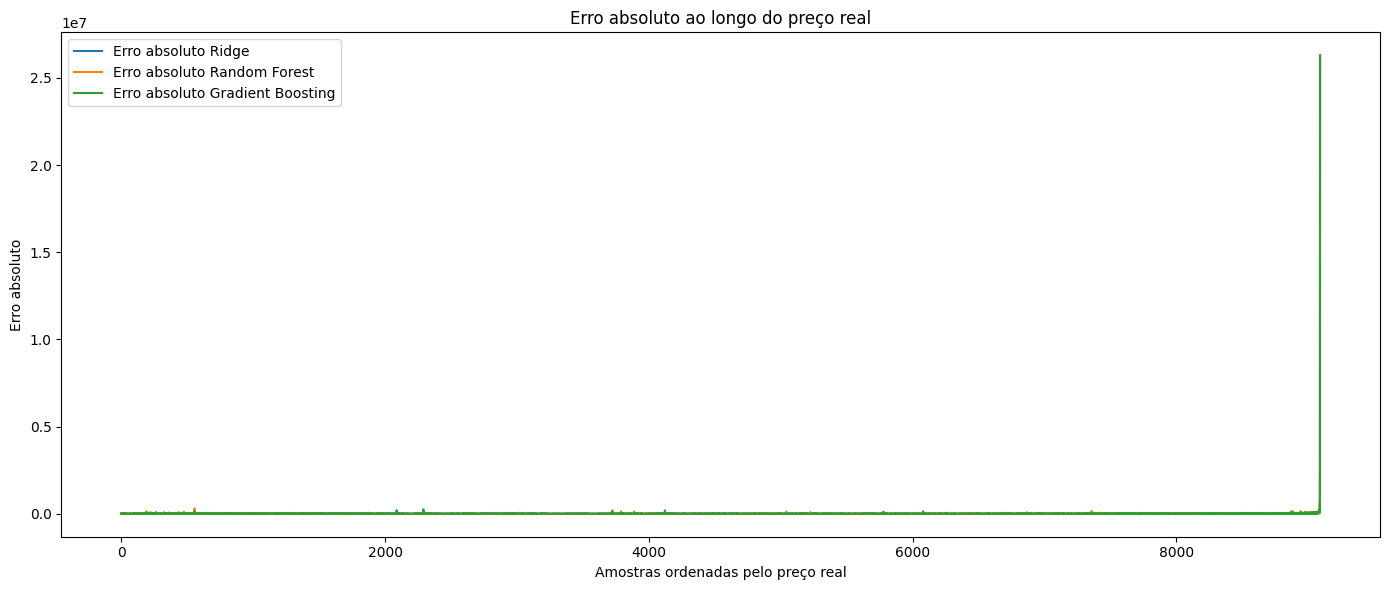

In [19]:
plt.figure(figsize=(14, 6))
plt.plot(df_plot["erro_abs_ridge"].values, label="Erro absoluto Ridge")
plt.plot(df_plot["erro_abs_rf"].values, label="Erro absoluto Random Forest")
plt.plot(df_plot["erro_abs_gb"].values, label="Erro absoluto Gradient Boosting")
plt.xlabel("Amostras ordenadas pelo preço real")
plt.ylabel("Erro absoluto")
plt.title("Erro absoluto ao longo do preço real")
plt.legend()
plt.tight_layout()
plt.show()